In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.utils import resample

In [2]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

print("NaN after cleaning:", df.isna().sum().sum())

NaN after cleaning: 0


In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

y_tr = y_train.values
X_maj = X_train_sc[y_tr == 0]
X_min = X_train_sc[y_tr == 1]
X_min_up = resample(X_min, replace=True, n_samples=len(X_maj), random_state=42)
X_train_res = np.vstack([X_maj, X_min_up])
y_train_res = np.hstack([np.zeros(len(X_maj)), np.ones(len(X_min_up))])
print(f"Balanced set: {X_train_res.shape}, NaN: {np.isnan(X_train_res).sum()}")

Balanced set: (800, 8), NaN: 0


In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost':            AdaBoostClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':           SVC(probability=True, kernel='rbf', random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("\n📊 Cross-Validation Results (5-Fold):")
print(f"{'Model':<25} {'CV Accuracy':>12} {'CV AUC':>10}")
print("-" * 50)

for name, model in models.items():
    cv_acc = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='accuracy').mean()
    cv_auc = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring='roc_auc').mean()
    model.fit(X_train_res, y_train_res)
    results[name] = {'model': model, 'cv_acc': cv_acc, 'cv_auc': cv_auc}
    print(f"{name:<25} {cv_acc:>12.4f} {cv_auc:>10.4f}")


📊 Cross-Validation Results (5-Fold):
Model                      CV Accuracy     CV AUC
--------------------------------------------------
Logistic Regression             0.7325     0.8303
Random Forest                   0.8688     0.9554
Gradient Boosting               0.8412     0.9273
AdaBoost                        0.7675     0.8474
SVM (RBF)                       0.7913     0.8671


In [7]:
best_name = max(results, key=lambda k: results[k]['cv_auc'])
best_model = results[best_name]['model']
print(f"\nBest Model: {best_name}")

y_pred   = best_model.predict(X_test_sc)
y_prob   = best_model.predict_proba(X_test_sc)[:, 1]
test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test ROC-AUC  : {test_auc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=['No Diabetes','Diabetes'])}")


Best Model: Random Forest
Test Accuracy : 0.7078
Test ROC-AUC  : 0.8108

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.76      0.80      0.78       100
    Diabetes       0.59      0.54      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.70       154



PermissionError: [Errno 13] Permission denied: '/diabetes_results.png'

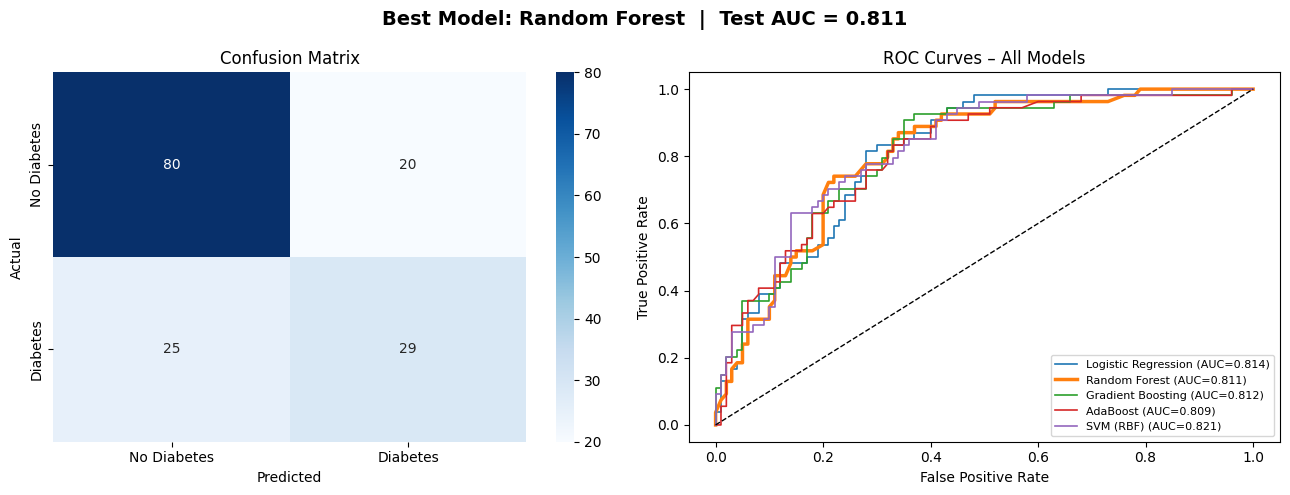

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Best Model: {best_name}  |  Test AUC = {test_auc:.3f}', fontsize=14, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

for name, res in results.items():
    prob = res['model'].predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[1].plot(fpr, tpr, lw=2.5 if name == best_name else 1.2,
                 label=f"{name} (AUC={auc:.3f})")

axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_title('ROC Curves – All Models')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/diabetes_results.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nResults plot saved. Done!")

In [10]:
import joblib

joblib.dump(best_model, 'diabetes_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')

print("Model and scaler saved!")

Model and scaler saved!
